# 최초 감염까지의 시간 분석을 통한 무작위 배정 시험의 백신 효능 추정

## 요약

## 무작위 배정 시험으로부터의 백신 효능 추정

핵심적인 3상 백신 시험에서는 참가자를 1:1로 **백신** 또는 **위약**에 무작위 배정하고, 각 참가자를 최초의 실험실 확진 감염 시점까지 또는 등록-추적 관찰 기간 종료 시점의 행정적 중도절단까지 추적한다. 규제 당국의 일차 평가변수는 **백신 효능(VE)**으로, `VE = 1 - 위험비(백신 대 위약)`로 정의된다. 참가자들이 시차를 두고 등록되며 대부분은 감염되지 않기 때문에, 데이터는 우측 중도절단되며 단순 비율이 아닌 생존 분석 방법이 방어 가능한 추정치를 제공한다.

이 노트북은 **100명(백신 50명, 위약 50명)**의 균형 잡힌 합성 시험 데이터로 이 평가변수를 처음부터 끝까지 다룬다:

- **PROC FREQ**는 카이제곱 검정, 상대위험도, 위험도 차이와 함께 발병률 2×2 표(군별 감염 상태)를 작성한다 — 임상 심사자가 가장 먼저 보는 기술적 "조 VE" 관점이다.
- **PROC MEANS**는 인시(person-time, 총 및 평균 추적 관찰 일수)와 군별 원시 감염 건수를 요약하여, 시간 대 사건 모형이 필요한 이유가 되는 중도절단 불균형을 드러낸다.
- **PROC LIFETEST**는 군별 Kaplan-Meier 생존 곡선을 추정하고 **로그순위(log-rank) 및 Wilcoxon** 동질성 검정을 수행한다 — 곡선이 분리됨을 확인하는 비모수적 검증이다.
- **PROC PHREG**는 연령, 성별, 기저 노출 위험을 보정한 Cox 비례위험 모형을 적합하고, 95% 신뢰한계와 함께 위험비를 보고하며, **HAZARDRATIO** 문은 군 간 대비를 직접 제시한다. 보정된 VE는 `1 - HR`로 읽는다.

**결과를 읽는 방법.** 검증된 실행에서 조 감염 비율은 **위약군 64% 대 백신군 30%**(카이제곱 p = 0.0007)이고, 로그순위 검정은 생존 곡선의 동일성을 기각하며(χ² = 11.25, p = 0.0008), 백신 대 위약의 보정 Cox 위험비는 95% CI **(0.198, 0.687)**의 **0.369**로 전부 1보다 작다 — 즉 약 **63%**(`1 - 0.369`)의 추정 VE이다. HR 상한 신뢰한계 0.687은 약 31%의 하한 효능에 대응하며, 이 정도로 작은 연구에서는 통상적인 30-50% 허가 기준의 가장자리에 있다. 기저의 고노출 직업은 감염 위험을 대략 세 배로 높이며(HR = 3.47, p < .0001) 공변량 보정이 중요함을 확인해 준다. 연령과 성별은 0.05 수준에서 유의성에 도달하지 못하는 경계선상의 효과(p ≈ 0.06)를 가진다. 조 2×2 표, 분리된 KM 곡선, 보정 Cox 추정치의 일관성은 효능을 선언하기에 앞서 데이터 안전성 모니터링 위원회가 기대하는 바로 그 삼각 검증이다.

*합성 데이터 전용 — `streaminit`/`rand`로 인라인 생성; 외부 파일이나 네트워크 없음. 1분 이내로 실행됨.*

## 데이터 출처

**합성 데이터셋 `trial`** — 등록된 참가자당 한 행으로, 첫 번째 코드 셀에서 인라인으로 생성됨(시드 `20260605`). 100명, 1:1 균형(백신 50명, 위약 50명), 백신군에서 약 70% 위험 감소를 갖는 지수 분포 최초 감염 시간, 시차 등록, 그리고 540일 기간 종료 시점의 행정적 중도절단.

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `subjid` | 수치 | 대상자 식별자 (1-100) |
| `arm` | 문자 | 처리군: `Vaccine` 또는 `Placebo` |
| `arm_n` | 수치 | 수치형 군 플래그 (1 = 백신, 0 = 위약) |
| `age` | 수치 | 등록 시점의 연령(년) (18-85) |
| `sex` | 문자 | 성별: `F` 또는 `M` |
| `baseline_risk` | 수치 | 고노출 직업 지표 (1 = 예) |
| `fu_days` | 수치 | 최초 감염 또는 중도절단까지의 추적 관찰 시간(일) |
| `infected` | 수치 | 사건 지표: 1 = 감염 관찰됨, 0 = 중도절단 |

# 무작위 배정 시험으로부터의 백신 효능 추정

**최초 감염까지의 시간 생존 분석**

백신 시험의 일차 효능 평가변수는 위약 대비 백신군의 **감염 위험(hazard)**이다. 우리는 다음과 같이 정의한다

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

참가자들이 시차를 두고 등록되며 대부분은 추적 관찰 종료 전에 감염되지 않기 때문에, 데이터는 우측 중도절단된다: 단순 감염 비율 비교는 시점 정보를 낭비하고 불균등한 추적 관찰로 인해 편향된다. 따라서 우리는 세 층위로 추정치를 구성하고 — 조 발병률 2×2 표, 로그순위 검정을 동반한 비모수 Kaplan-Meier 곡선, 그리고 보정 Cox 비례위험 모형 — 세 가지 모두 동일한 이야기를 하는지 확인한다.

이 분석은 **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST**, **PROC PHREG**를 사용한다.

## 1. 합성 시험 데이터 생성

우리는 균형 잡힌 100명, 1:1 무작위 배정 시험(백신 50명, 위약 50명 — 대상자 홀짝에 따라 배정하여 군이 정확히 동일하도록 함)을 시뮬레이션한다. 최초 감염까지의 시간은 일별 위험이 군(백신은 위험을 위약의 30%로 낮춤), 연령, 고노출 직업 플래그에 따라 달라지는 지수 분포에서 추출된다. 시차 등록에 고정된 540일 기간을 더하면 현실적인 우측 중도절단이 생성된다: 추적 관찰 종료 시점까지 감염되지 않은 사람은 누구든 중도절단된다.

In [1]:
/* 합성 무작위배정 백신 시험: 최초 감염까지의 시간 */
데이터 trial;
    호출 streaminit(20260605);
    길이 arm $12 sex $6;
    enroll_days = 540;            /* 등록 + 추적관찰 기간 */
    반복 subjid = 1 까지 100;
        /* 백신군 대 위약군 1:1 무작위배정: 군당 50명,
           정확히 균형된 시험을 위해 홀짝으로 배정 */
        만약 mod(subjid, 2) = 1 이면 반복;
            arm = '백신'; arm_n = 1;
        종료;
        아니면 반복;
            arm = '위약'; arm_n = 0;
        종료;

        /* 기저 공변량 */
        AGE = round(rand('NORMAL', 47, 14));
        만약 AGE < 18 이면 AGE = 18;
        만약 AGE > 85 이면 AGE = 85;
        만약 rand('BERNOULLI', 0.52) = 1 이면 sex = '여'; 아니면 sex = '남';
        baseline_risk = rand('BERNOULLI', 0.30);   /* 고노출 직업 */

        /* 일별 감염 위험도: 위약 기준, 백신은 약 70% 감소 */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        만약 arm_n = 1 이면 ve_factor = 0.30; 아니면 ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* 지수 위험도로부터 최초 감염까지의 시간 */
        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        /* 시차 등록에 따른 행정적 중도절단 */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        만약 t_inf <= t_cens 이면 반복;
            fu_days = round(t_inf);
            infected = 1;
        종료;
        아니면 반복;
            fu_days = round(t_cens);
            infected = 0;
        종료;
        만약 fu_days < 1 이면 fu_days = 1;
        출력;
    종료;
    유지 subjid arm arm_n AGE sex baseline_risk fu_days infected;
실행;


NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 발병률 2×2 표

가장 단순한 효능 관점: 군을 감염 상태와 교차 집계한다. 카이제곱 검정은 감염이 군과 독립인지를 묻는다; `RELRISK`은 상대위험도와 교차비를 보고한다; `RISKDIFF`는 신뢰구간과 함께 절대 위험도 차이를 제공한다. 이것은 *조*(보정되지 않고 추적 관찰을 무시한) 관점으로 — 타당성 점검으로는 유용하지만 규제용 추정치는 아니다.

                                                   The FREQ Procedure

Table of 배정군 by 감염 발생

배정군       |         0 |         1 |      Total
----------+-----------+-----------+-----------
백신        |        35 |        15 |         50
----------+-----------+-----------+-----------
위약        |        18 |        32 |         50
----------+-----------+-----------+-----------
Total     |        53 |        47 |        100

Statistics for Table of 배정군 by 감염 발생

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient                      0.3406
Contingency Coefficient              0.3224
Cramer's V                           0.3406


Column 1 Risk Estimates

Risk (Row 1)                         0.7000
Risk (Row 2) 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


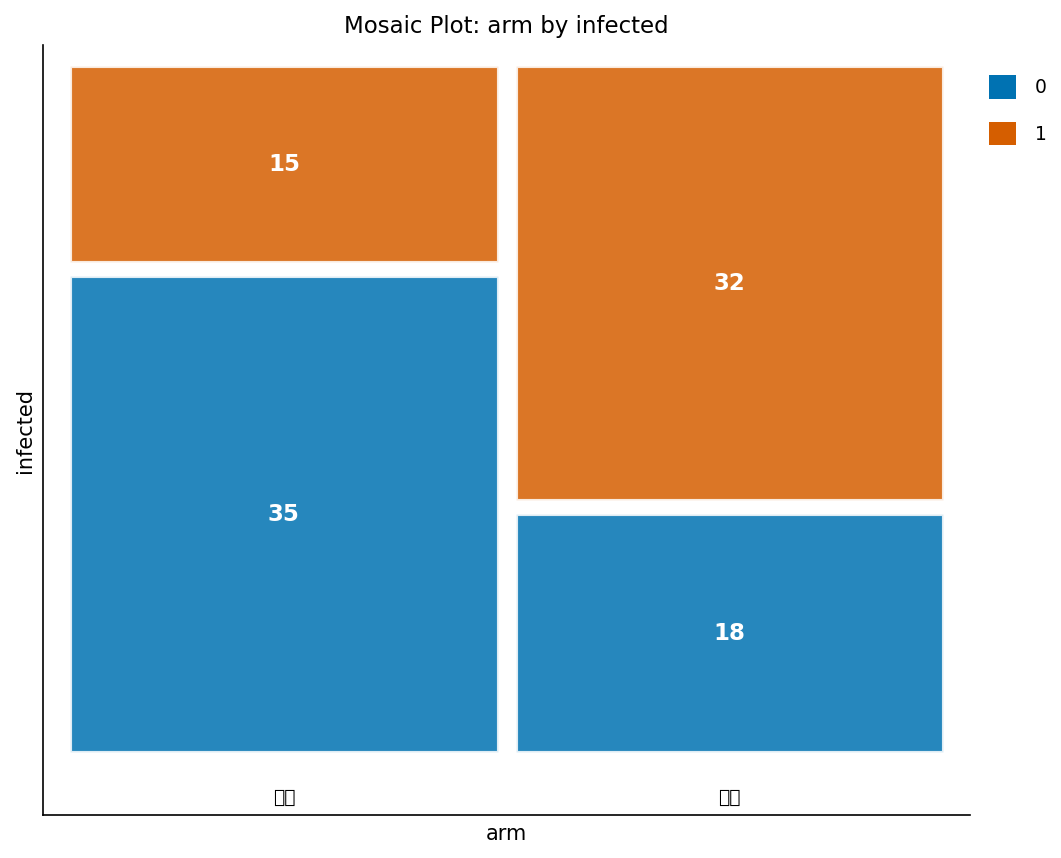

In [2]:
처리 빈도 데이터=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
    라벨 arm='배정군' infected='감염 발생';
실행;

## 3. 군별 인시와 사건 건수

조 2×2 표를 신뢰하기 전에 우리는 추적 관찰 불균형을 정량화한다. `PROC MEANS`는 각 군의 총 및 평균 추적 관찰 일수와 감염 건수를 보고한다. 만약 백신군이 *더 많은* 인시를 축적한다면(초기 사건이 더 적다면), 조 비율은 효능을 과소평가하는 것이다 — 이것이 바로 다음에 시간 대 사건 모형으로 넘어가는 이유이다.

In [3]:
처리 평균 데이터=trial n sum mean maxdec=2;
    분류 arm;
    변수 fu_days infected;
    라벨 arm='배정군' fu_days='추적관찰 기간(일)' infected='감염 발생';
실행;

                                                  The MEANS Procedure

                                  Analysis Variable : fu_days 추적관찰 기간(일)

        배정군                N Obs            Sum           Mean
        ------------------------------------------------------
        백신                    50       19438.00         388.76
        위약                    50       14552.00         291.04
        ------------------------------------------------------

                                       Analysis Variable : infected 감염 발생

        배정군                N Obs            Sum           Mean
        ------------------------------------------------------
        백신                    50          15.00           0.30
        위약                    50          32.00           0.64
        ------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Kaplan-Meier 곡선과 로그순위 검정

`PROC LIFETEST`는 곱-극한(Kaplan-Meier) 생존 함수 — 여기서는 시간 경과에 따라 감염되지 않은 상태로 남아 있을 확률 — 를 각 군별로 별도로 추정한다. `STRATA arm / test=(logrank wilcoxon)`는 두 가지 표준 동질성 검정을 요청한다: **로그순위** 검정은 모든 사건 시점에 동일한 가중치를 부여하며(비례위험 가정 하에서 가장 검정력이 높음), **Wilcoxon**은 초기 사건에 더 큰 가중치를 부여한다. 둘 사이의 일치는 Cox 모형이 의존할 비례위험 가정을 뒷받침한다. `ATRISK`는 여전히 위험에 처한 인원 수를 주석으로 표시한다.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

Stratum: 배정군 = 백신

                 N
--------  --------
Total           50
Event           15
Censored        35

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
 42.0000    0.9800     0.0198              50                 1
 51.0000    0.9600     0.0277              49                 1
 57.0000    0.9400     0.0336              48                 1
 79.0000    0.9200     0.0384              47                 1
 81.0000    0.9000     0.0424              46                 1
 88.0000    0.8800     0.0460              45                 1
 98.0000    0.8600     0.0491              44                 1
216.0000    0.8400     0.


NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


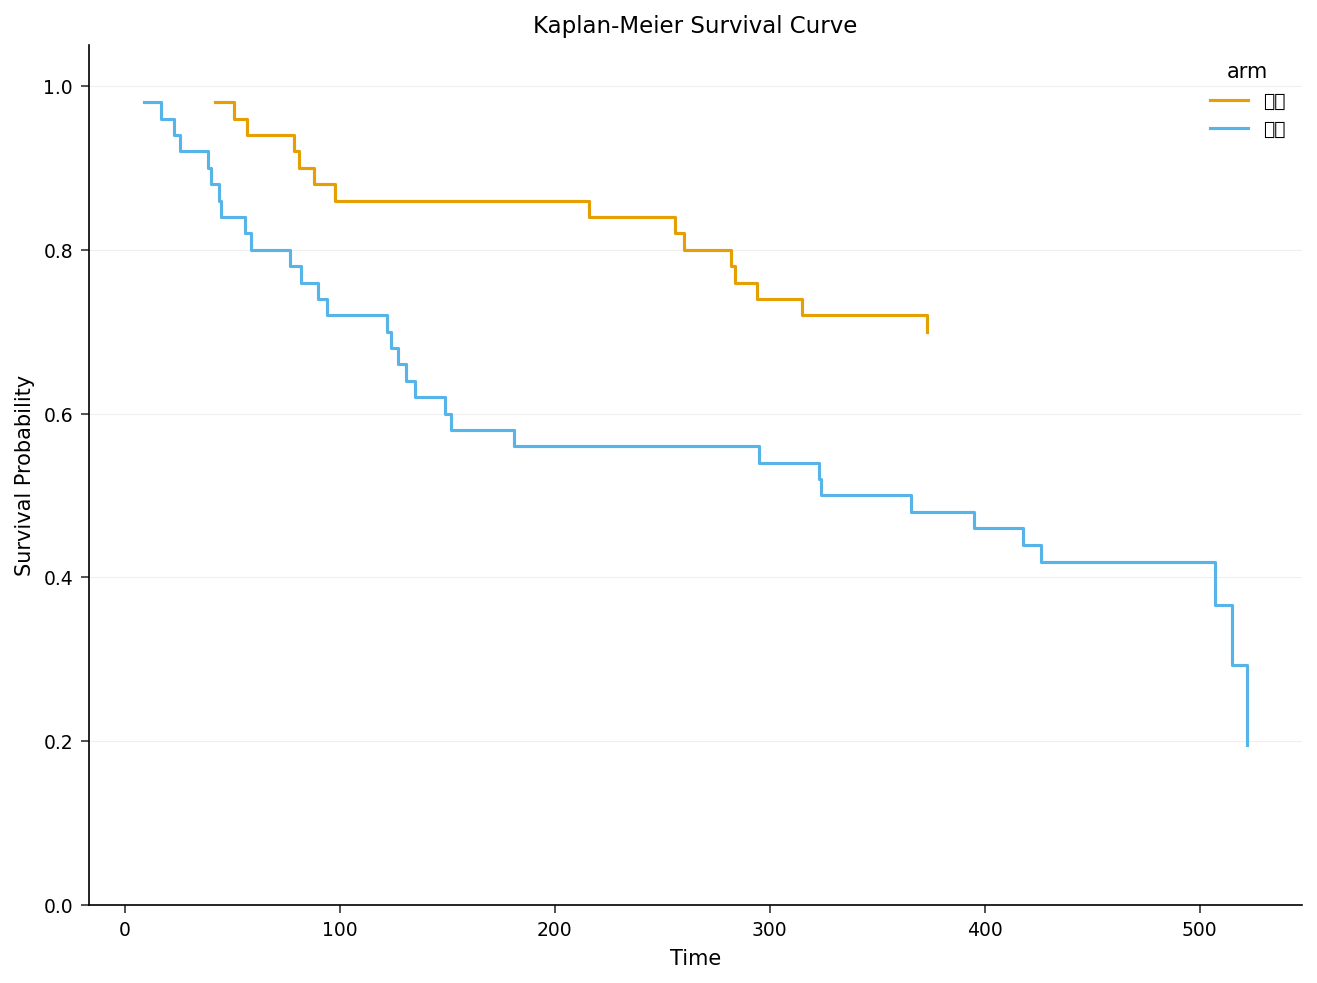

In [4]:
처리 LIFETEST 데이터=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
    라벨 fu_days='추적관찰 기간(일)' arm='배정군';
실행;

## 5. 보정 Cox 모형과 백신 효능

Cox 비례위험 모형은 연령, 성별, 기저 노출 위험을 통제한 **보정** 위험비를 제공한다. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref`는 참조 코딩을 설정하여 `ARM` 계수가 백신 대 위약의 로그 위험비가 되도록 한다. `TIES=EFRON`은 권장되는 동점 처리 방법이다; `RL`은 위험비 신뢰한계를 출력한다. `HAZARDRATIO` 문은 군 간 대비(Wald CL)와 10년 증가당 연령 효과를 보고한다.

**백신 효능은 군 항에 대해 `VE = 1 - HR`로 직접 읽으며**, HR의 상한 신뢰한계는 허가 결정이 좌우되는 하한 효능에 대응한다.

In [5]:
처리 PHREG 데이터=trial;
    분류 arm(REF='위약') sex(REF='남') / PARAM=REF;
    모형 fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    hazardratio '백신 대 위약' arm / cl=wald;
    hazardratio AGE / units=10;
    라벨 fu_days='추적관찰 기간(일)' arm='배정군' AGE='연령(세)'
          sex='성별' baseline_risk='고노출 직업 여부';
실행;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                          Analysis of Maximum Likelihood Estimates                                           

Parameter                      DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-----------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
ARM_백신                 


NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 해석

세 층위는 하나의 효능 결론으로 삼각 수렴한다:

- **조 발병률 (PROC FREQ).** 감염 비율은 **위약군 64%(32/50) 대 백신군 30%(15/50)**로 — 위험도 차이 **-0.34**(95% CI -0.524 ~ -0.156), 교차비 **0.241**(95% CI 0.105 ~ 0.556)이다. 카이제곱 검정은 독립성을 기각한다(χ² = 11.60, p = 0.0007). 이것은 심사자가 가장 먼저 기대하는 한눈에 보는 신호이지만 — 시차가 있고 불균등한 추적 관찰을 무시한다.

- **인시 (PROC MEANS).** 평균 추적 관찰은 백신군에서 더 길다(**388.8일 대 291.0일**). 이는 바로 더 적은 참가자가 감염을 통해 조기에 이탈하기 때문이다(백신 사건 15건 대 위약 32건). 이는 조 비율이 보수적이고 추적 관찰이 교란된 관점임을 확인해 주며 시간 대 사건 분석을 정당화한다.

- **Kaplan-Meier + 로그순위 (PROC LIFETEST).** 생존 곡선은 명확히 분리된다 — 위약군은 **감염 없는 중앙값 시간 324일**에 도달하는 반면 **백신군의 중앙값은 도달되지 않는다**(백신 접종자 50명 중 15명만 감염됨). 두 동질성 검정 모두 동일성을 기각한다: **로그순위 χ² = 11.25 (p = 0.0008)**, **Wilcoxon χ² = 9.11 (p = 0.0025)**. 둘의 일치는 Cox 모형의 근간이 되는 비례위험 가정을 뒷받침한다.

- **보정 Cox 모형 (PROC PHREG).** 연령, 성별, 기저 노출 위험을 보정한 후, 백신 대 위약의 위험비는 95% CI **(0.198, 0.687)**의 **0.369**로 전부 1보다 작으며(p = 0.0017), 약 **63%**(`VE = 1 - 0.369`)의 추정 **백신 효능**을 제공한다. 하한 효능(HR 상한 신뢰한계 0.687로부터)은 **31%** 근처로, 통상적인 30-50% 허가 기준의 가장자리에 있다 — 100명 규모 연구에서 예상되듯 폭이 넓다. 고노출 직업은 감염 위험을 대략 세 배로 높이며(**HR = 3.47**, 95% CI 1.90-6.35, p < .0001) 공변량 보정이 타당함을 확인해 준다; 연령(HR = 1.022/년, p = 0.059)과 여성 성별(HR = 0.541, p = 0.064)은 0.05 수준에서 유의성에 도달하지 못하는 경계선상의 효과를 가진다. 전역 귀무가설은 기각된다(우도비 χ² = 29.0, p < .0001).

**결론.** 조 2×2 표, 분리된 Kaplan-Meier 곡선, 보정 Cox 추정치가 모두 동일한 방향을 가리키고 신뢰구간이 무효과를 배제하므로, 이 시험은 효능 신호를 뒷받침한다 — 다만 넓은 신뢰한계는 작은 표본을 반영한다. 실제 허가 신청에서는 조 비율이 아니라 Cox `1 - HR` 추정치와 그 신뢰구간이 일차 평가변수가 되며, FREQ와 LIFETEST 출력은 데이터 안전성 모니터링 위원회가 함께 검토하는 뒷받침용 기술적·비모수적 검증 역할을 한다.